# FFT Signal Processing Notebook

Notebook ini disusun untuk belajar bertahap:

1. Sinyal sintetis (palsu)
- Ubah parameter sinyal dengan mudah.
- Lihat dampaknya di domain waktu.
- Lanjut ke FFT untuk memahami puncak frekuensi.

Urutan eksekusi yang disarankan:
- Jalankan cell dari atas ke bawah.

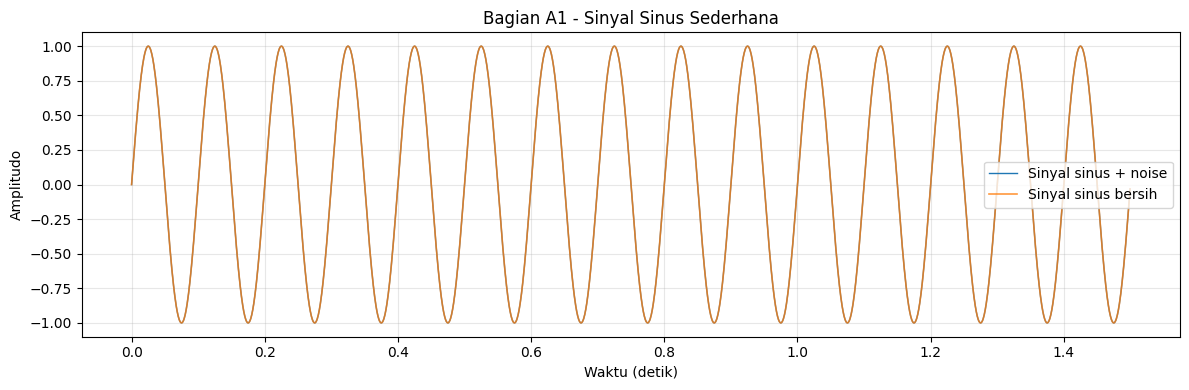

syn_fs = 2000 Hz | durasi = 1.5 s | sampel = 3000
Frekuensi sinus utama = 10 Hz | amplitudo = 1.0
noise std = 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# BAGIAN A1 - SINYAL SEDERHANA (1 SINUS)
# ======================================================
# Parameter utama (mudah diubah)
syn_fs = 2000           # Sampling frequency (Hz)
syn_duration = 1.5      # Durasi (detik)
syn_f0 = 10             # Frekuensi sinus utama (Hz)
syn_amp0 = 1.0          # Amplitudo sinus
syn_phase0 = 0.0        # Fase awal (radian)
syn_noise_std = 0.0     # Noise (0.0 = tanpa noise)
syn_random_seed = 42

# Sumbu waktu
t = np.arange(0, syn_duration, 1 / syn_fs)

# Sinyal sinus bersih
syn_clean_signal = syn_amp0 * np.sin(2 * np.pi * syn_f0 * t + syn_phase0)

# Noise Gaussian opsional
rng = np.random.default_rng(syn_random_seed)
syn_noise = rng.normal(0, syn_noise_std, size=t.shape)
syn_signal = syn_clean_signal + syn_noise

# Simpan untuk cell FFT berikutnya
syn_n = len(syn_signal)

# Plot domain waktu
plt.figure(figsize=(12, 4))
plt.plot(t, syn_signal, lw=1.0, color="tab:blue", label="Sinyal sinus + noise")
plt.plot(t, syn_clean_signal, lw=1.2, color="tab:orange", alpha=0.8, label="Sinyal sinus bersih")
plt.title("Bagian A1 - Sinyal Sinus Sederhana")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"syn_fs = {syn_fs} Hz | durasi = {syn_duration} s | sampel = {syn_n}")
print(f"Frekuensi sinus utama = {syn_f0} Hz | amplitudo = {syn_amp0}")
print(f"noise std = {syn_noise_std}")

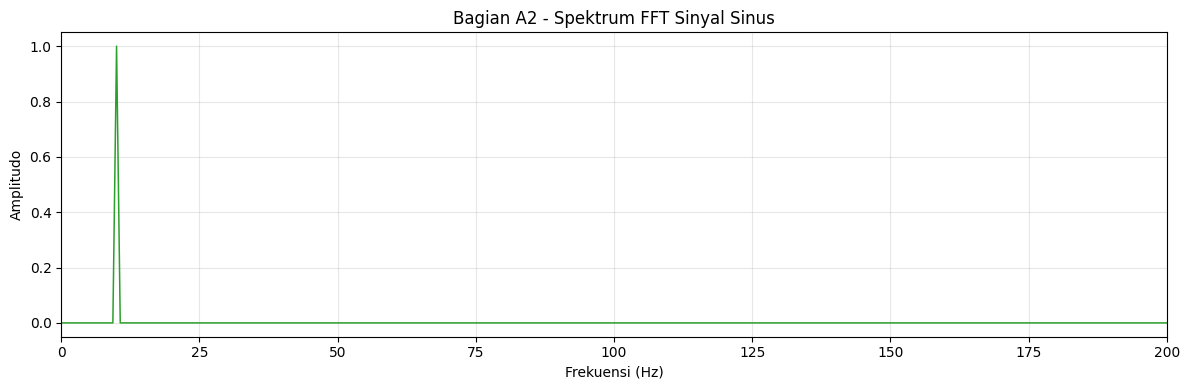

Frekuensi puncak FFT = 10.00 Hz
Amplitudo puncak     = 1.0000
Target frekuensi     = 10 Hz


In [2]:
# ======================================================
# BAGIAN A2 - FFT DARI SINYAL SINUS SEDERHANA
# ======================================================
# 1) Hilangkan offset DC
syn_signal_centered = syn_signal - np.mean(syn_signal)

# 2) Hitung FFT satu sisi
syn_freqs = np.fft.rfftfreq(syn_n, d=1 / syn_fs)
syn_fft_vals = np.fft.rfft(syn_signal_centered)
syn_amp = (2 / syn_n) * np.abs(syn_fft_vals)

# 3) Plot spektrum
plt.figure(figsize=(12, 4))
plt.plot(syn_freqs, syn_amp, color="tab:green", lw=1.1)
plt.title("Bagian A2 - Spektrum FFT Sinyal Sinus")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# 4) Frekuensi puncak utama
peak_idx = np.argmax(syn_amp[1:]) + 1
peak_freq = syn_freqs[peak_idx]
peak_amp = syn_amp[peak_idx]

print(f"Frekuensi puncak FFT = {peak_freq:.2f} Hz")
print(f"Amplitudo puncak     = {peak_amp:.4f}")
print(f"Target frekuensi     = {syn_f0} Hz")